In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
a = 1.0       # Коэффициент теплопроводности
B = 1.0       # Коэффициент в начальном условии
L = 1.0       # Длина стержня
T = 0.1 

In [3]:
Nx = 100      # Количество узлов по пространству
Nt = 1000     # Количество узлов по времени
dx = L / (Nx - 1)
dt = T / (Nt - 1)

In [4]:
r = (a**2) * dt / (dx**2)
if r > 0.5:
    print(f"Внимание: схема может быть неустойчива (r = {r:.2f} > 0.5)")


Внимание: схема может быть неустойчива (r = 0.98 > 0.5)


In [5]:
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)
U = np.zeros((Nx, Nt))

In [6]:
U[:, 0] = B * x**3

In [8]:
for j in range(0, Nt - 1):
    for i in range(1, Nx - 1):
        U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
    
    # Граничное условие на правом конце (используем аппроксимацию второго порядка)
    U[-1, j + 1] = (4 * U[-2, j + 1] - U[-3, j + 1]) / 3  # dU/dx = 0 (изолированный конец)

D:\Users\Boris\AppData\Local\Temp\ipykernel_16084\734894049.py:3: RuntimeWarning: overflow encountered in scalar add
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
D:\Users\Boris\AppData\Local\Temp\ipykernel_16084\734894049.py:3: RuntimeWarning: overflow encountered in scalar subtract
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
D:\Users\Boris\AppData\Local\Temp\ipykernel_16084\734894049.py:3: RuntimeWarning: overflow encountered in scalar multiply
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])
D:\Users\Boris\AppData\Local\Temp\ipykernel_16084\734894049.py:3: RuntimeWarning: invalid value encountered in scalar add
  U[i, j + 1] = U[i, j] + r * (U[i + 1, j] - 2 * U[i, j] + U[i - 1, j])


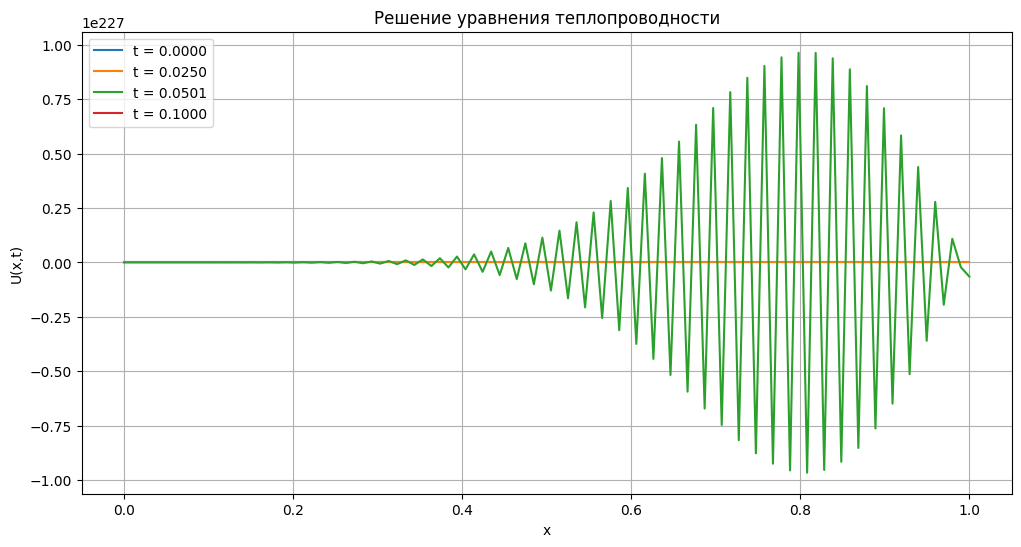

In [9]:
plt.figure(figsize=(12, 6))

# Температурное поле в разные моменты времени
for j in [0, Nt//4, Nt//2, Nt-1]:
    plt.plot(x, U[:, j], label=f't = {t[j]:.4f}')

plt.title('Решение уравнения теплопроводности')
plt.xlabel('x')
plt.ylabel('U(x,t)')
plt.legend()
plt.grid(True)
plt.show()

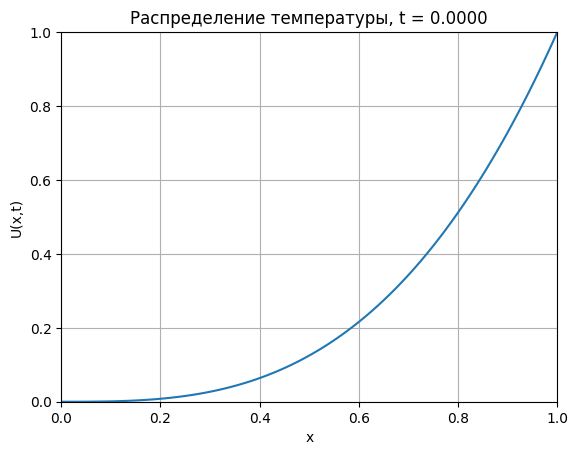

In [10]:
animate = True
if animate:
    from matplotlib.animation import FuncAnimation
    
    fig, ax = plt.subplots()
    line, = ax.plot(x, U[:, 0])
    ax.set_xlim(0, L)
    ax.set_ylim(0, B*L**3)
    ax.set_xlabel('x')
    ax.set_ylabel('U(x,t)')
    ax.set_title('Распределение температуры по времени')
    ax.grid(True)
    
    def update(frame):
        line.set_ydata(U[:, frame])
        ax.set_title(f'Распределение температуры, t = {t[frame]:.4f}')
        return line,
    
    ani = FuncAnimation(fig, update, frames=range(0, Nt, Nt//50), 
                        interval=50, blit=True)
    plt.show()